# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** M. Fadlan Fadilah
- **Email:** fadlanfadilah250@gmail.com
- **ID Dicoding:** fadlanfadilah

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren pertumbuhan total pendapatan (revenue) bulanan untuk 3 kategori produk dengan volume penjualan tertinggi sepanjang tahun 2018?
- **Pertanyaan 2:** Negara bagian (state) manakah yang menyumbang volume pensanan terbanyak untuk kategori produk terlaris tersebut selama tahun 2018?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

`folium` di sini digunakan untuk melakukan Geospatial Analysis.

## Data Wrangling

### Gathering Data

#### Load df ...

In [4]:
# memuat data ke dalam DataFrame
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
customers_df = pd.read_csv("customers_dataset.csv")

# orders_df.head()

**Insight:**
- Dataset ini memiliki struktur seperti Relational Database yang dinormalisasi. Datanya terpisah dan dihubungkan oleh Primary key dan Foreign key.
- Dikarenakan struktur datanya terpisah, pada tahap EDA nanti akan dipastikan perlu melakukan proses penggabungan tabel untuk mendapatkan satu dataframe utuh sebagai bahan analisis.

### Assessing Data

#### Identifying ... problem

**-- Assessing Tabel Orders --**

In [5]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Steps to take:
- Mengonversi tipe data pada 5 kolom waktu di tabel orders_df dari object menjadi datetime

Insight:
- Masalah tipe data: tedapat 5 kolom yang mendeskripsikan tanggal dan waktu pengiriman. Saat ini, kolom-kolom tersebut memiliki tipe data object. Ini akan menghambat proses agregasi deret waktu bulanan.
- Terdapat missing value (null) pada kolom `order_approved_at` dan tanggal pengiriman.


**-- Assessing Tabel Order Items --**

In [6]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


Steps to take:
- Mengonversi tipedata pada kolom `shipping_limit_date` di tabel products_df menjadi datetime.

Insight:
- Masalah tipe data: Kolom shipping_limit_date terbaca sebagai object. Perlu dikonversi menjadi datetime.

-- Assessing Tabel Products --

In [7]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


Steps to take:
- menangani missing value pada kolom product_category_name dengan melakukan imputasi.

Insight:
- Masalah missing value: Terdapat beberapa missing value pada kolom yang sangat krusial, yaitu product_category_name. Menghapus baris ini berisiko menghilangkan nilai pendapatan yang signifikan. Solusinya adalah melakukan imputasi dengan mengisi nilai yang kosong dengan label string "Unknown"

-- Assessing Tabel Customers --

In [8]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


Steps to take:
- Membiarkan missing value pada kolom tanggal pengiriman di orders_df karena analisis pendapatan hanya bergantung pada waktu pesanan dibuat.

Insight:
- Tidak ditemukan masalah tipe data yang salah ataupun missing value yang signifikan.

### Cleaning Data

#### Fixing ... problem

**Memperbaiki Tipe Data Waktu**

In [9]:
# mengubah tipe data tanggal di orders_df
datetime_columns_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns_orders:
  orders_df[column] = pd.to_datetime(orders_df[column])

# mengubah tipe data tanggal di order_items_df
order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])

print(orders_df["order_purchase_timestamp"].dtypes)

datetime64[ns]


**Menangani Missing Value**

In [10]:
# mengisi missing value di kolom kategori produk
products_df["product_category_name"] = products_df['product_category_name'].fillna("Unknown")

print("Sisa missing value kategori:", products_df["product_category_name"].isna().sum())

Sisa missing value kategori: 0


Insight:
- Perbaikan tipe data (pada orders_df) perlu dilakukan agar perhitungan tren waktu bulanan dapat dilakukan.
- Dikarenakan kolom product_category_name (pada products_df) merupakan variabel utama untuk menjawab pertanyaan bisnis, menghapus baris berisiko merusak kalkulasi total pendapatan jika produk tersebut ternyata memiliki nilai transaksi besar.

## Exploratory Data Analysis (EDA)

### Explore ...

In [11]:
# menggabungkan data pesanan dengan detail harganya
main_df = pd.merge(
    left=orders_df,
    right=order_items_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

# menambahkan informasi nama kategori produk
main_df = pd.merge(
    left=main_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"

)

# menambahkan informasi lokasi pelanggan
main_df = pd.merge(
    left=main_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

# menambahkan kolom 'tahun' dan 'bulan' agar mudah dianalisis
main_df['order_year'] = main_df['order_purchase_timestamp'].dt.year
main_df['order_month_num'] = main_df['order_purchase_timestamp'].dt.month

# melihat ukuran data dan lima baris pertama
print("Ukuran main_df:", main_df.shape)
main_df.head()

Ukuran main_df: (113425, 28)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_year,order_month_num
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018,2


**Insight:**
- Proses merging (menggunakan LEFT JOIN) berhasil menyatukan tabel-tabel relasional yang terpisah menjadi satu dataframe utama (`main_df). Data yang awalnya tersebar kini terdenormalisasi dalam satu wadah.

**Pertanyaan Bisnis 1**: Tren total pendapatan bulanan untuk 3 kategori produk terlaris di tahun 2018.

In [12]:
# filter data hanya untuk pesanan tahun 2018
df_2018 = main_df[main_df['order_year'] == 2018]

# mencari 3 kategori produk dengan volume penjualan tertinggi di 2018
top_3_categories = df_2018['product_category_name'].value_counts().head(3).index.tolist()
print("3 Kategori Produk Terlaris dii 2018:", top_3_categories)

# filetr data untuk 3 kategori terlaris
df_top_categories_2018 = df_2018[df_2018['product_category_name'].isin(top_3_categories)]

# melakukan agregasi untuk menghitung total pendapatan per bulan
revenue_trend = df_top_categories_2018.groupby(by=['order_month_num', 'product_category_name']).agg({
    'price': 'sum'
}).reset_index()

# mengubah nama kolom
revenue_trend.rename(columns={'price': 'total_revenue'}, inplace=True)
revenue_trend.head(10)

3 Kategori Produk Terlaris dii 2018: ['beleza_saude', 'cama_mesa_banho', 'informatica_acessorios']


,order_month_num,product_category_name,total_revenue
0,1,beleza_saude,72470.49
1,1,cama_mesa_banho,76377.79
2,1,informatica_acessorios,83257.45
3,2,beleza_saude,86996.06
4,2,cama_mesa_banho,60690.88
5,2,informatica_acessorios,100855.23
6,3,beleza_saude,90034.41
7,3,cama_mesa_banho,69256.39
8,3,informatica_acessorios,85673.53
9,4,beleza_saude,91751.04


Insight:
- Filter data berhasil mengidentifikasi 3 kategori produk penyumbang volume pesanan tertinggi di tahun 2018, yaitu beleza_saude, cama_mesa_banho, dan informatica_acessorios.
- Agregasi bulanan telah sukses meringkas jutaan baris transaksi menjadi metrik total_revenue per kategori setiap bulannya. Terlihat persaingan pendapatan yang cukup ketat antara beleza_saude dan informatica_acessorios di bulan awal-awal.

**Pertanyaan Bisnis 2**: Negara bagian mana yang menyumbang volume pesanan terbanyak untuk kategori terlaris tersebut di 2018?

In [13]:
state_orders = df_top_categories_2018.groupby(by='customer_state').agg({
    'order_id': 'nunique' # mneghitung jumlah order unik
}).reset_index()

# mengurutkan
state_orders = state_orders.sort_values(by='order_id', ascending=False)
state_orders.rename(columns={'order)id': 'total_orders'}, inplace=True)

# tampilkan 5 negara bagian teratas
state_orders.head()

,customer_state,order_id
25,SP,6672
18,RJ,1733
10,MG,1706
22,RS,705
17,PR,620


Insight:
- Hasil agregasi pesanan unik per wilayah menunjukkan ketimpangan distribusi yang sangat tajam. Negara bagian SP (Sao Paulo) mendomnasi secara absolut dengan  total 6.672 pesanan untuk tiga kategori unggulan tersebut.
- Volume pesanan di SP hampir mencapai 4 kali lipat dari peringkat kedua, yaitu RJ dengan 1.733 pesanan, disusul ketat oleh MG dengan 1.706 pesanan. Metrik demografis ini mengindikasikan bahwa infrastruktur logistik dan fokus marketing sebaiknya dikonsentrasikan pada segitiga wilayah SP, RJ, dan MG ini.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

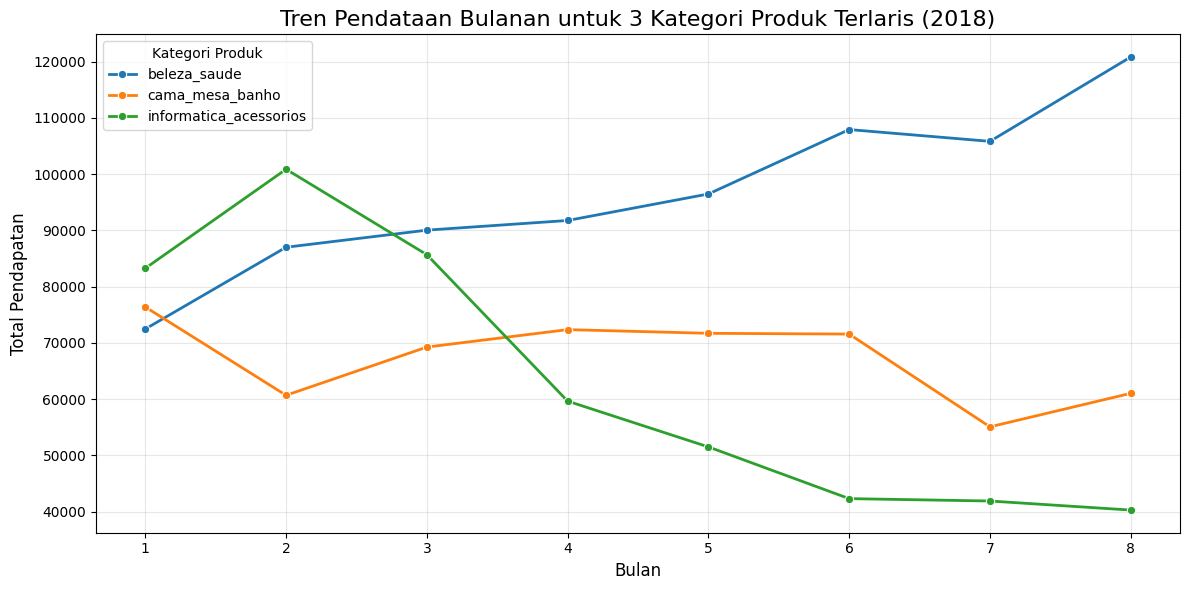

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=revenue_trend,
    x='order_month_num',
    y='total_revenue',
    hue='product_category_name',
    marker='o',
    linewidth=2
)

plt.title('Tren Pendataan Bulanan untuk 3 Kategori Produk Terlaris (2018)', fontsize=16)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Pendapatan', fontsize=12)
plt.xticks(range(1, 9))
plt.grid(True, alpha=0.3)
plt.legend(title='Kategori Produk')
plt.tight_layout()
plt.show()

Insight:
- Terlihat adanya fluktuasi tren pendapatan yang dinamis dari bulan ke bulan pada ketiga kategori produk terlaris sepanjang tahun 2018.


### Pertanyaan 2:

<function matplotlib.pyplot.show(close=None, block=None)>

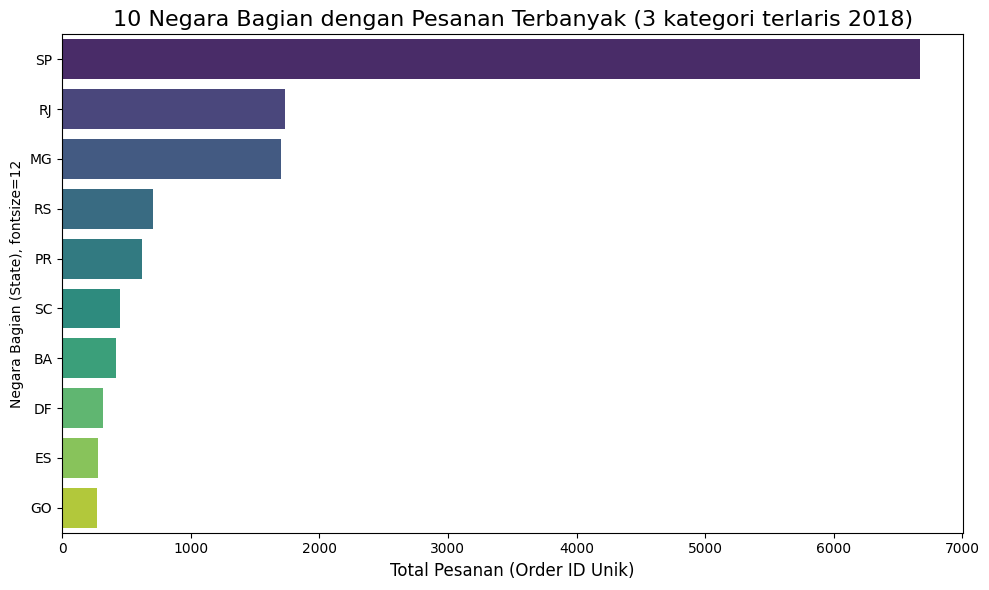

In [15]:
plt.figure(figsize=(10, 6))

#mengambil top 10 state
sns.barplot(
    data=state_orders.head(10),
    x='order_id',
    y='customer_state',
    hue='customer_state',
    palette='viridis',
    legend=False
)

plt.title('10 Negara Bagian dengan Pesanan Terbanyak (3 kategori terlaris 2018)', fontsize=16)
plt.xlabel('Total Pesanan (Order ID Unik)', fontsize=12)
plt.ylabel('Negara Bagian (State), fontsize=12')
plt.tight_layout()
plt.show

Insight:
- Terlihat adanya ketimpangan distribusi pesanan antar negara bagian tergambar dengan sangat jelas.
- Panjang batang visual untuk SP terlihat membentang nyaris 4 kali lipat lebih panjang dibanding RJ yang menyusul di posisi kedua. Hal ini mengonfirmasi bahwa pusat gravitasi pasar e-commerce tersebut mutlak berada di SP.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan analisis tren pendapatan sepanjang tahun 2018, ketiga produk terlaris (beleza_saude, cama_mesa_banho, informatica_acessorios) menunjukkan fluktuasi pendapatan bulanan yang sangat dinamis.
- **Conclusion pertanyaan 2:** Analisis distribusi geografis memperlihatkan dominasi wilayah yang absolut. Negara bagian SP menjadi pusat penyumbang volume pesanan terbanyak (6.672 pesanan) untuk kategori produk terlaris, melampaui wilayah peringkat kedua (RJ) dan ketiga (MG) dengan jarak volume hampir 4 kali lipat.

**Rekomendasi Action Item:**
- Karena pesanan terpusat di wilayah SP, perusahaan harus memprioritaskan pembangunan atau perluasan kapasitas pusat distribusi di area tersebut. Ini akan memberikan dampak instan pada penurunan ongkos kirim pelanggan dan mempercepat estimasi waktu pengiriman.
- Tim pemasaran dan manajemen gudang perlu memanfaatkan data tren bulanan pada ketiga kategori terlaris. Stok barang harus diamankan sebelum memasuki bulan dengan tren puncak, sementara anggaran promosi harus dialokasikan secara agresif pada bulan-bulan di mana kurva tern pendapatan terlihat menurun.

In [16]:
main_df.to_csv("main_data.csv", index=False)